# OmniSearch — Closed Loop: Sim → UAV view → Detection

This notebook drives the full perception loop:

1. **Simulator** — VMAS `WildfireSearchScenario` advances under a (random) policy.
2. **Synthetic UAV view** — every K steps we paint the scenario's state into a 512×512 top-down image: orange tiles where fire cells burn, real person sprites at survivor positions (so YOLOv8 actually fires on them).
3. **Detection pipeline** — the same `DetectionPipeline` (fire → YOLOv8 person → alert) used on real UAV footage runs on this synthetic image.
4. **Ground truth scoring** — because the simulator knows where everything is, we get free precision/recall metrics for the perception pipeline.

The policy is **random**. The point is to validate perception, not policy quality. Plug a trained policy in via the `action_fn` argument to `run_closed_loop`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from evaluation import run_closed_loop, UAVRenderer
from detection import DetectionPipeline

## 1. Run the closed loop

120 sim steps, render every 15 → 8 frames evaluated.  Takes ~10 s on CPU (YOLOv8 dominates).

In [2]:
run = run_closed_loop(n_steps=120, render_every=15, seed=42)
summary = run.summary()
print(f"frames rendered: {run.n_frames}")
print(f"alerts fired:    {run.n_alerts}")
for k, v in summary.items():
    print(f"  {k:30}: {v}")

frames rendered: 8
alerts fired:    6
  n_frames                      : 8
  n_alerts                      : 6
  person_tp                     : 40
  person_fp                     : 9
  person_fn                     : 0
  person_precision              : 0.816
  person_recall                 : 1.0
  fire_presence_accuracy        : 1.0


## 2. Visualise each frame

For every rendered step we overlay:
- **green** boxes: persons YOLOv8 detected and matched to a ground-truth survivor
- **yellow** boxes: false positive person detections
- **red** boxes: persons flagged as "survivor in fire" (the alert subset)
- **orange** boxes: fire regions detected

Watch how the fire grows and the alert flips from False → True as it reaches a survivor.

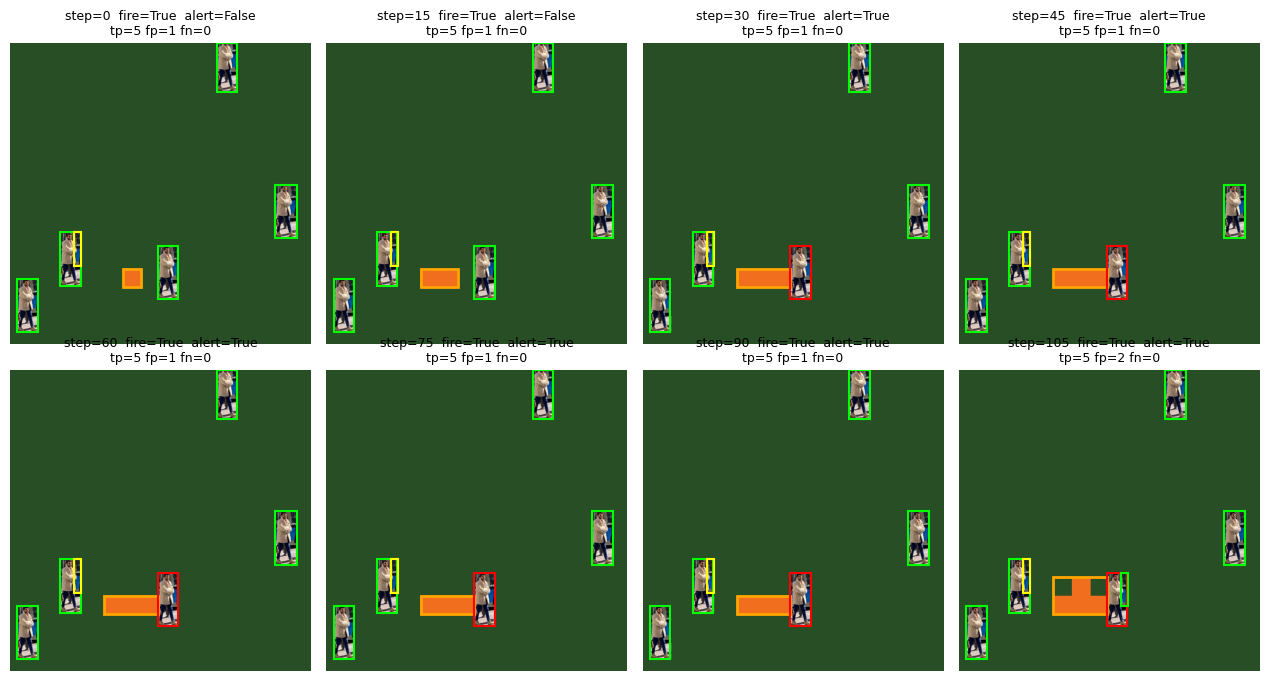

In [3]:
def draw_frame(ax, frame):
    ax.imshow(frame.image)
    # Fire boxes
    for f in frame.pipeline.fire.detections:
        x1, y1, x2, y2 = f.box
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor='orange', facecolor='none'))
    # Person boxes — green if matched to GT, yellow otherwise, red if in fire
    gt = list(frame.ground_truth.survivor_pixel_boxes)
    in_fire_ids = set(id(p) for p in frame.pipeline.survivors_in_fire)
    matched = [False] * len(gt)
    for p in frame.pipeline.persons.detections:
        x1, y1, x2, y2 = p.box
        if id(p) in in_fire_ids:
            color = 'red'
        else:
            color = 'yellow'
            for ti, t in enumerate(gt):
                if not matched[ti]:
                    tx1, ty1, tx2, ty2 = t
                    if x2 + 8 >= tx1 and tx2 + 8 >= x1 and y2 + 8 >= ty1 and ty2 + 8 >= y1:
                        matched[ti] = True
                        color = 'lime'
                        break
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=1.5, edgecolor=color, facecolor='none'))
    ax.set_title(f"step={frame.step}  fire={frame.fire_detected}  alert={frame.pipeline.alert}\n"
                 f"tp={frame.tp_persons} fp={frame.fp_persons} fn={frame.fn_persons}",
                 fontsize=9)
    ax.axis('off')

n = len(run.frames)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.4))
for ax, frame in zip(axes.flatten(), run.frames):
    draw_frame(ax, frame)
for ax in axes.flatten()[n:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Alert timeline

When does the perception pipeline raise the alarm? This plot shows three signals over time:

- **Fire detected** (orange) — fire pipeline returned ≥1 detection
- **Person ↔ fire overlap** (red) — at least one person box overlaps a fire region
- **Ground-truth fire present** (gray dashed) — the simulator's fire grid actually has burning cells

The red line lagging behind the orange one is the meaningful event: fire was visible for a while before it threatened a survivor.

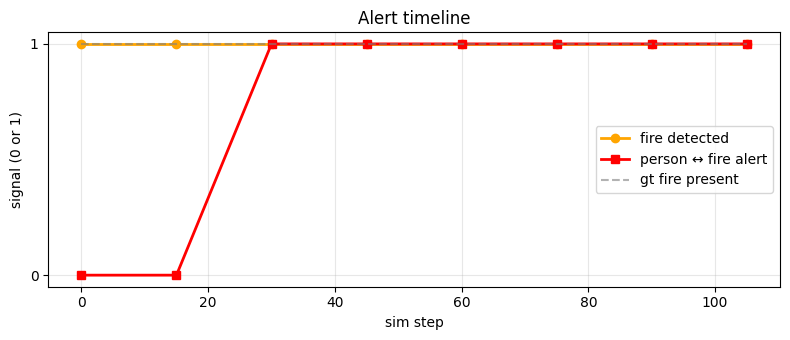

In [4]:
steps      = [f.step for f in run.frames]
fire_det   = [int(f.fire_detected)         for f in run.frames]
alerts     = [int(f.pipeline.alert)        for f in run.frames]
fire_gt    = [int(f.fire_in_gt)            for f in run.frames]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(steps, fire_det, marker='o', color='orange',  linewidth=2, label='fire detected')
ax.plot(steps, alerts,   marker='s', color='red',     linewidth=2, label='person ↔ fire alert')
ax.plot(steps, fire_gt,  linestyle='--', color='gray', alpha=0.6,   label='gt fire present')
ax.set_xlabel('sim step')
ax.set_ylabel('signal (0 or 1)')
ax.set_title('Alert timeline')
ax.set_yticks([0, 1])
ax.legend(loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Plugging in a trained policy

`run_closed_loop` accepts an `action_fn(env) → actions` callable. To rollout a BenchMARL-trained policy, load the actor from a checkpoint and adapt it to VMAS's per-agent action lists. Sketch:

```python
import torch
from benchmarl.experiment import Experiment

experiment = Experiment.reload_from_file('results/mappo_wildfire_search_mlp__.../checkpoint_xxx.pt')
actor = experiment.algorithm.get_policy_for_collection()

def policy_fn(env):
    # Convert env.observations → TensorDict → actor → per-agent action list.
    # See benchmarl/experiment/experiment.py for the exact key plumbing.
    ...

run = run_closed_loop(action_fn=policy_fn, ...)
```

Smoke training doesn't save checkpoints — use the research budget (`comms_dropout_sweep.py --research` or a config with `checkpoint_at_end=True`) to produce a loadable model.